# Setup


📝 *Import required libraries and files:*

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [2]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

### 4.2.1. - Prepare df for model training

In [3]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    653426.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

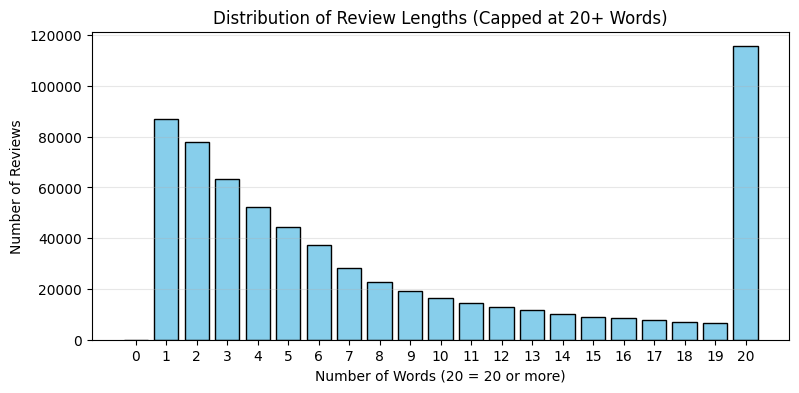

In [4]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
print(f"Total reviews: {len(df)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are after October 1, 2021
df_sub1 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] > pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub1 after filtering: {len(df_sub1)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are before October 1, 2021
df_sub2 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] <= pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub2 after filtering: {len(df_sub2)}")

Total reviews: 653426
Total reviews of df_sub1 after filtering: 212971
Total reviews of df_sub2 after filtering: 174448


In [6]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst", "best"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo", "app", "banking", "bank"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text", name="df"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    print(f"Shape of {name} before cleaning: {df.shape}")
    
    df["bert_" + col] = df[col].astype(str) # Create a new column for cleaned text
    cleaned_col = "bert_" + col

    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces

    for w in STOP_WORDS:
        df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    # elimnate rows with less than 2 words after cleaning
    df = df[df[cleaned_col].str.split().str.len() >= 2].copy()

    # print number of rows after cleaning
    print(f"Shape of {name} after cleaning: {df.shape}")

    return df

In [7]:
# Perform cleaning on both df_sub1 (recent reviews that will be used for training) and df_sub2 (for later inference)
df_sub1 = bertopic_cleaning(df_sub1, col="review_text", name="df_sub1")
df_sub2 = bertopic_cleaning(df_sub2, col="review_text", name="df_sub2")

Shape of df_sub1 before cleaning: (212971, 22)
Shape of df_sub1 after cleaning: (212700, 23)
Shape of df_sub2 before cleaning: (174448, 22)
Shape of df_sub2 after cleaning: (174210, 23)


In [8]:
df_sub1.head(2)

,ID,app,score,review_text,review_text_clean,review_date,year,thumbs_up,replied,reply_text,...,app_version_head,app_version_detail,review_sentiment,review_sentiment_label,Consistent,reply_sentiment,reply_sentiment_label,word_count,word_count_capped,bert_review_text
0,1,Santander,2,extremely irritating that you can't use an old...,extremely irritating that you can't use an old...,2025-10-20 08:36:34,2025,0,1,Hey there! All feedback is greatly appreciated...,...,5,24.0,-0.5095,negative,1,0.7339,positive,24,20,extremely irritating that you can't use an old...
2,3,Santander,4,Please stop forcing us to update the app. This...,please stop forcing us to update the app. this...,2025-10-19 16:10:13,2025,0,1,"Hi Michael, sorry to hear you're having issues...",...,5,27.0,-0.7717,negative,1,0.7003,positive,33,20,Please stop forcing us to update the . This ha...


In [9]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings_sub1 = embedding_model.encode(
    df_sub1["bert_review_text"].to_list(), 
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings_sub2 = embedding_model.encode(
    df_sub2["bert_review_text"].to_list(), 
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/6647 [00:00<?, ?it/s]

Batches:   0%|          | 0/5445 [00:00<?, ?it/s]

In [10]:
# Create directory one level up from the notebook folder
os.makedirs("../assets/models/bertopic", exist_ok=True)

# Save the files
np.save("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy", embeddings_sub1)
np.save("../assets/models/bertopic/embeddings_sub2_miniLM_L6.npy", embeddings_sub2)

## 4.2.2. - Unseeded topic modelling

### 4.2.2.1. - Model Training

In [11]:
# Load embeddings
embeddings_sub1 = np.load("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy")

In [12]:
# Dimensionality reduction tuned for short reviews
umap_model = UMAP(
    n_neighbors=30,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tends to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility

# Clustering tuned for short reviews
hdbscan_model = HDBSCAN(
    min_cluster_size=150,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.3,    # Merge clusters within 0.3 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Vectorizer 
STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS + list(ENGLISH_STOP_WORDS)
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=10,                 # ignores terms appearing in less than 'n' documents
    max_df=0.5                # ignores terms appearing in more than 'x%' of documents
)

# Create the BERTopic model
unseed_topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    verbose=True)

In [13]:
topics, probs = unseed_topic_model.fit_transform(df_sub1["bert_review_text"].to_list(), embeddings_sub1)

2025-10-24 17:26:32,926 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-24 17:32:17,883 - BERTopic - Dimensionality - Completed ✓
2025-10-24 17:32:17,916 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-24 17:37:37,371 - BERTopic - Cluster - Completed ✓
2025-10-24 17:37:37,420 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-24 17:37:42,564 - BERTopic - Representation - Completed ✓


In [14]:
# Save Bertopic model 
unseed_topic_model.save("../assets/models/bertopic/unseed_model")

2025-10-24 17:37:43,625 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.2.2. - Model evaluation and finetune

In [15]:
unseed_topic_model = BERTopic.load("../assets/models/bertopic/unseed_model")

In [16]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_accounts_credit_payments_banks,"[accounts, credit, payments, banks, payment, c...",[Good in general. I the feature showing the ba...
1,0,79320,0_payments_payment_exchange_crypto,"[payments, payment, exchange, crypto, transfer...",[Very handy during travelling when need to exc...
2,1,22081,1_use works_use does_use helpful_need easy,"[use works, use does, use helpful, need easy, ...","[Straight forward to use so helpful to me, Ver..."
3,2,8774,2_secure easy_use secure_reliable easy_safe easy,"[secure easy, use secure, reliable easy, safe ...","[Safe and secure, easy to navigate., Safe and ..."
4,3,8567,3_good far_good like_great good_good thanks,"[good far, good like, great good, good thanks,...","[Good I like it., Been Good so far, good so far]"
...,...,...,...,...,...
59,58,167,58_options easy_use options_lots options_optio...,"[options easy, use options, lots options, opti...","[Many options and easy to use., many options, ..."
60,59,163,59_use functional_functional easy_fluid_functi...,"[use functional, functional easy, fluid, funct...","[Easy to use and very functional., really easy..."
61,60,161,60_2024_2025_2022_2023,"[2024, 2025, 2022, 2023, 2020, march, june, 20...",[A very good . Not been disappointed to date. ...
62,61,158,61_banks_change banks_changing banks_switch,"[banks, change banks, changing banks, switch, ...",[Changing phone trying to put on new phone it ...


In [17]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
NEW_STOP_WORDS = STOP_WORDS + GENERAL_WORDS

new_vectorizer = CountVectorizer(stop_words= NEW_STOP_WORDS , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
unseed_topic_model.update_topics(
    df_sub1["bert_review_text"].to_list(),                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [18]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_account_money_phone_im,"[account, money, phone, im, ive, credit, acces...",[Good in general. I the feature showing the ba...
1,0,79320,0_money_card_account_update,"[money, card, account, update, transfer, log, ...",[Very handy during travelling when need to exc...
2,1,22081,1_problems_problem_ive_problems problems,"[problems, problem, ive, problems problems, co...","[Straight forward to use so helpful to me, Ver..."
3,2,8774,2_secure_security_secure secure_secure security,"[secure, security, secure secure, secure secur...","[Safe and secure, easy to navigate., Safe and ..."
4,3,8567,3_ok_im_enjoying_lovely,"[ok, im, enjoying, lovely, cool, seen, world, ...","[Good I like it., Been Good so far, good so far]"
...,...,...,...,...,...
59,58,167,58_options_options options_available options_o...,"[options, options options, available options, ...","[Many options and easy to use., many options, ..."
60,59,163,59_functional_functional functional_fluid_func...,"[functional, functional functional, fluid, fun...","[Easy to use and very functional., really easy..."
61,60,161,60_2024_2025_2022_2023,"[2024, 2025, 2022, 2023, 2020, march, june, 20...",[A very good . Not been disappointed to date. ...
62,61,158,61_banks_switch banks_changing banks_switch,"[banks, switch banks, changing banks, switch, ...",[Changing phone trying to put on new phone it ...


In [19]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

In [20]:
# keep original untouched
unseed_try = copy.deepcopy(unseed_topic_model)

In [21]:
# reduce the number of topics
unseed_try.reduce_topics(df_sub1["bert_review_text"].to_list(), nr_topics=25)

2025-10-24 17:38:36,698 - BERTopic - Topic reduction - Reducing number of topics
2025-10-24 17:38:36,896 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-24 17:38:42,395 - BERTopic - Representation - Completed ✓
2025-10-24 17:38:42,424 - BERTopic - Topic reduction - Reduced number of topics from 64 to 25


Exploration of the reduced set of topics

In [22]:
unseed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_account_money_phone_im,"[account, money, phone, im, ive, card, transfe...",[very good website. extremely user friendly. g...
1,0,91221,0_account_money_card_update,"[account, money, card, update, pay, transfer, ...",[always quick and easy to transfer money to ot...
2,1,63424,1_service_secure_navigate_friendly,"[service, secure, navigate, friendly, problems...","[better than any other service., Easy to use a..."
3,2,10542,2_im_ok_lovely_enjoying,"[im, ok, lovely, enjoying, cool, ive, moment, ...","[all ok. easy enough., Ok... But could do bett..."
4,3,2463,3_chat_statements_support_help,"[chat, statements, support, help, download, me...","[and the 'live chat' is absolutely ., chat is ..."
5,4,1643,4_notifications_notification_push_push notific...,"[notifications, notification, push, push notif...","[good until notifications stopped otherwise, R..."
6,5,1590,5_concise_information_clearer_friendly,"[concise, information, clearer, friendly, user...",[Works well every time I use it. Clear and con...
7,6,1203,6_la_que_si_en,"[la, que, si, en, el, es, et, se, nu, una]",[Es el medio de pago con el que menos sorpresa...
8,7,1015,7_review_rating_rate_asking,"[review, rating, rate, asking, reviews, asking...",[great. I give 5 and I like . if something hap...
9,8,984,8_branches_local_closed_visit,"[branches, local, closed, visit, closing, staf...",[Makes it so easy to do now tiara are very few...


In [23]:
# Visualize topics as a hierarchical tree
fig = unseed_try.visualize_hierarchy()
fig.show()

In [24]:
unseed_try.visualize_barchart(width = 280, height = 330, top_n_topics=15, n_words=10)

The unseeded model, even before the reduction, created significant concentration of reviews in one dominant topic - topic 0. After reduction, both topic 0 and topic 1 clearly dominate, absorbing a huge proportion of reviews, which diminishes the insights given by this model so far. Let's examinate the main dominant topic to see if we can extract something more from there.

In [25]:
# further analysis on dominant topic
dominant_topic = 0 
big_topic_docs = [df_sub1["bert_review_text"].to_list()[i] for i, t in enumerate(topics) if t == dominant_topic]

In [26]:
big_topic_embs = np.array([embeddings_sub1[i] for i, t in enumerate(topics) if t == dominant_topic])

In [27]:
# Smaller, more local neighborhood = finer clusters
umap_model = UMAP(
    n_neighbors=15,       # fewer neighbors → more detailed clusters
    n_components=10,      # 5–15 usually works well
    min_dist=0.0,
    metric="cosine"
)

# Allow smaller topic sizes than before
hdbscan_model = HDBSCAN(
    min_cluster_size=1000, 
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

subtopic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

In [28]:
sub_topics, sub_probs = subtopic_model.fit_transform(big_topic_docs, big_topic_embs)

2025-10-24 17:46:17,697 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-24 17:47:39,593 - BERTopic - Dimensionality - Completed ✓
2025-10-24 17:47:39,603 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-24 17:48:30,859 - BERTopic - Cluster - Completed ✓
2025-10-24 17:48:30,876 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-24 17:48:33,412 - BERTopic - Representation - Completed ✓


In [29]:
subtopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,679,-1_glitches_receipt_screenshot_to,"[glitches, receipt, screenshot, to, screenshot...",[Good and works well. the only frustration is ...
1,0,35318,0_the_to_and_my,"[the, to, and, my, it, is, not, account, this,...","[I enjoy the , but it's so annoying that I hav..."
2,1,20737,1_to_and_easy_money,"[to, and, easy, money, the, it, use, for, tran...","[It's easy to use and send money, This is horr..."
3,2,9040,2_for_and_exchange_to,"[for, and, exchange, to, great, currency, easy...",[It is good to use especially when you travel ...
4,3,7518,3_card_the_to_and,"[card, the, to, and, my, for, it, is, use, cards]","[I this card and, card to have, My card is]"
5,4,2864,4_crypto_and_for_to,"[crypto, and, for, to, the, stocks, is, tradin...","[I like it for Crypto, Great , for crypto, Gre..."
6,5,1647,5_balance_the_widget_to,"[balance, the, widget, to, is, it, and, see, q...","[Since the last update to the , It has changed..."
7,6,1517,6_the_premium_to_you,"[the, premium, to, you, they, for, and, plan, ...",[Do not pay for premium. It is not. I paid for...


As it can be seen, the unseeded model continues to show a propensity to create big cluster of reviews, even after trying to create a subtopic_model on top of the dominant topic. We could do some additional finetune to 'force' the creation of smaller clusters. However, since we already know which type of issues/topics are we dealing with, we will try a different modelling approach using a seeded list and check if we get better results.

## 4.2.3. -  Seeded Topic Modeling

#### 4.2.3.1. - Model Training

In [30]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [31]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    stop_words = STOP_WORDS,
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [32]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(df_sub1["bert_review_text"].to_list(), embeddings_sub1)

2025-10-24 17:48:34,029 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-24 17:59:23,712 - BERTopic - Dimensionality - Completed ✓
2025-10-24 17:59:23,722 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-24 18:17:25,020 - BERTopic - Cluster - Completed ✓
2025-10-24 18:17:25,084 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-24 18:17:35,101 - BERTopic - Representation - Completed ✓


In [33]:
# Save Bertopic model 
seed_topic_model.save("../assets/models/bertopic/seed_model")

2025-10-24 18:17:38,572 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.3.2. - Model evaluation and finetune

In [34]:
seed_topic_model = BERTopic.load("../assets/models/bertopic/seed_model")

In [35]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,87567,-1_card_log_payments_transfer,"[card, log, payments, transfer, accounts, tran...",[Initially worked fine but for close to a week...
1,0,4456,0_card_cards_use card_debit,"[card, cards, use card, debit, card great, new...","[A great card to have, The card so far 👍, card..."
2,1,4174,1_easy easy_makes life_life easier_easy quick,"[easy easy, makes life, life easier, easy quic...","[Makes life so much easier!, Makes my life so ..."
3,2,3787,2_finances_spending_track_control,"[finances, spending, track, control, manage mo...",[Very handy and convenient to keep on top of y...
4,3,2916,3_close account_close_fraud_scam,"[close account, close, fraud, scam, closed, bl...","[Will not let me close the account, Doesn't le..."
...,...,...,...,...,...
186,185,155,185_server_timed_session_responding,"[server, timed, session, responding, servers, ...","[Used to find the very good but now, having re..."
187,186,153,186_comfortable_peace mind_peace_mind,"[comfortable, peace mind, peace, mind, comfort...","[very easy and comfortable, it and very comfor..."
188,187,152,187_early_day early_paid_paid early,"[early, day early, paid, paid early, earlier, ...",[easy and having the option to get paid a day ...
189,188,152,188_register_registration_reregister_registrat...,"[register, registration, reregister, registrat...","[I am trying to register, Wouldn't even let me..."


In [36]:
# keep original untouched
seed_try = copy.deepcopy(seed_topic_model)

# Save topics before reduction
topics_before_reduction = np.array(topics)  

In [37]:
# Reduce topics - modifies the model and returns it
seed_try = seed_try.reduce_topics(df_sub1["bert_review_text"].to_list(), nr_topics=101)

2025-10-24 18:18:38,790 - BERTopic - Topic reduction - Reducing number of topics
2025-10-24 18:18:39,075 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-24 18:18:48,795 - BERTopic - Representation - Completed ✓
2025-10-24 18:18:48,834 - BERTopic - Topic reduction - Reduced number of topics from 191 to 101


In [38]:
# Check the results
# pd.set_option("display.max_rows", None)   # enable to show all rows
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,87567,-1_log_payments_transfers_payment,"[log, payments, transfers, payment, credit, tr...","[very glitchy, kicks you out all the time, I c..."
1,0,13184,0_convenient easy_efficient easy_use convenien...,"[convenient easy, efficient easy, use convenie...","[Convenient & Very easy to use 😌, Very conveni..."
2,1,10408,1_transactions_finances_track_transfers,"[transactions, finances, track, transfers, mon...",[Very effective and reliable for all of my mob...
3,2,5404,2_exchange_currency_abroad_rates,"[exchange, currency, abroad, rates, currencies...",[It is very easy to travel with and great exch...
4,3,4834,3_cards_virtual_use card_virtual card,"[cards, virtual, use card, virtual card, debit...",[Very flexibile. I can issue lots of virtual c...
...,...,...,...,...,...
96,95,169,95_traditional_century_revolutionary_21st century,"[traditional, century, revolutionary, 21st cen...","[A 21st Century truly!, finally something true..."
97,96,158,96_2025_2024_2022_2023,"[2025, 2024, 2022, 2023, 2020, march, june, 20...","[still very good 2025, ! The people on the pho..."
98,97,155,97_use functional_functional easy_functionalit...,"[use functional, functional easy, functionalit...",[Really easy to use and functional . Highly re...
99,98,153,98_comfortable_peace mind_peace_comfortable using,"[comfortable, peace mind, peace, comfortable u...","[it and very comfortable., very comfortable an..."


In [39]:
# INSPECT TOPIC DETAILS

df = seed_try.get_document_info(df_sub1["bert_review_text"].to_list())
topic_id = 11

# Count number of documents for the topic
topic_count = df[df["Topic"] == topic_id].shape[0]
print(f"Number of documents in topic {topic_id}: {topic_count}\n")

# Get the words for the topic
topic_words = seed_try.get_topic(topic_id)
print(f"Top words for topic {topic_id}:\n")

for word, weight in topic_words:
    print(f"{word}: {weight:.4f}")
    
print ("\nTop documents for this topic:\n")

# Filter by topic and sort by probability
topic_docs = (
    df[df["Topic"] == topic_id]
    .sort_values("Probability", ascending=False)
    .head(10)["Document"]
    .tolist()
)

for i, doc in enumerate(topic_docs, 1):
    print(f"{i}. {doc}")

Number of documents in topic 11: 2820

Top words for topic 11:

account easy: 0.0806
accounts easy: 0.0482
manage accounts: 0.0404
manage account: 0.0353
check account: 0.0276
access accounts: 0.0260
account great: 0.0254
use account: 0.0216
account account: 0.0212
account good: 0.0203

Top documents for this topic:

1. Very easy to manage Account
2. easy to use, does everything I need to manage my account
3. Easy & quick to log on. Simple to use. All info I need. great
4. . easy to use and any where I can use my account
5. everythig super, but safety login its need to more safety
6. Easy able to keep up to date with account.
7. Complicated to learn if this is the first account of this type but works well.
8. Very user friendly, and so much easier to use than my previous back account.
9. It is very useful to have an account and very user friendly.
10. Exelent for everything account


In [40]:
# count the number of documents for selected topics merge

print("\nMONEY MGMT AND TRAVEL-related topics breakdown:")
# money management
money_mgmt_topic_ids = [1,11,12,28,63,75]
money_mgmt_count = df[df["Topic"].isin(money_mgmt_topic_ids)].shape[0]
print(f"- Money management: {money_mgmt_count}")
# travel and forex
travel_topic_ids = [2,85]
travel_count = df[df["Topic"].isin(travel_topic_ids)].shape[0]
print(f"- Travel and forex: {travel_count}")

print("\nUSER EXPERIENCE-related topics breakdown:")
# UX_simplicity
simplicity_topic_ids = [0,4,29,54,79,80,81,88]
simplicity_count = df[df["Topic"].isin(simplicity_topic_ids)].shape[0]
print(f"- Simplicity: {simplicity_count}")
# UX_usability (navigation and overall experience)
ux_topic_ids = [7,25,27,52,98]
ux_count = df[df["Topic"].isin(ux_topic_ids)].shape[0]
print(f"- Usability & interaction: {ux_count}")
# UX_interface, features and layout
interface_topic_ids = [13,48,56,69,90,97]
interface_count = df[df["Topic"].isin(interface_topic_ids)].shape[0]
print(f"- Interface, features and layout: {interface_count}")
# UX_notifications and adds
notifications_topic_ids = [23,65]
notifications_count = df[df["Topic"].isin(notifications_topic_ids)].shape[0]
print(f"- Notifications: {notifications_count}")

print("\nPERFORMANCE-related topics breakdown:")
# PERFORMANCE_stability - always works / available
stability_topic_ids = [19,38,47,71,72,87]
stability_count = df[df["Topic"].isin(stability_topic_ids)].shape[0]
print(f"- Stability ('always work/available'): {stability_count}")
# PERFORMANCE_updates
updates_topic_ids = [22,50]
updates_count = df[df["Topic"].isin(updates_topic_ids)].shape[0]
print(f"- Updates: {updates_count}")
# PERFORMANCE_compatability & launch issues
compatability_topic_ids = [33,35,42,44,68,91]
compatability_count = df[df["Topic"].isin(compatability_topic_ids)].shape[0]   
print(f"- Compatability and launch issues: {compatability_count}")
# PERFORMANCE_reliability - does what is expected
reliability_topic_ids = [15,18,43,73,74,86,93,94]
reliability_count = df[df["Topic"].isin(reliability_topic_ids)].shape[0]
print(f"- Reliability ('does what is expected'): {reliability_count}")
# PERFORMANCE_bugs with specific issues
bugs_topic_ids = [49,58,66,76,77,87]
bugs_count = df[df["Topic"].isin(bugs_topic_ids)].shape[0]
print(f"- Functional Bugs: {bugs_count}")

print("\nPRODUCT-related topics breakdown:")
# PRODUCT_cards
cards_topic_ids = [3,67]
cards_count = df[df["Topic"].isin(cards_topic_ids)].shape[0]
print(f"- Cards: {cards_count}")
# PRODUCT_investments & fees
investments_topic_ids = [16,36]
investments_count = df[df["Topic"].isin(investments_topic_ids)].shape[0]
print(f"- Investments & fees: {investments_count}")  
# PRODUCT_cheques
cheques_topic_ids = [10]
cheques_count = df[df["Topic"].isin(cheques_topic_ids)].shape[0]
print(f"- Cheque: {cheques_count}")
# PRODUCT_referral program
referral_topic_ids = [55]
referral_count = df[df["Topic"].isin(referral_topic_ids)].shape[0]
print(f"- Referral program: {referral_count}")

print("\nAUTHENTICATION AND SECURITY-related topics breakdown:")
# login & authentication
login_topic_ids = [8,21,32,62]
login_count = df[df["Topic"].isin(login_topic_ids)].shape[0]
print(f"- Login & authentication-related topics: {login_count}")
# security
security_topic_ids = [6,9]
security_count = df[df["Topic"].isin(security_topic_ids)].shape[0]
print(f"- Security: {security_count}")

print("\nCUSTOMER SERVICE-related topics breakdown:")
# customer support
support_topic_ids = [5,26,60,64]
support_count = df[df["Topic"].isin(support_topic_ids)].shape[0]
print(f"- Customer support: {support_count}")

# UNDEFINED
undefined_topic_ids = [14,17,20,24,30,31,34,37,39,40,41,45,46,51,53,57,59,61,70,78,82,83,84,89,92,95,96,99]
undefined_count = df[df["Topic"].isin(undefined_topic_ids)].shape[0]
print(f"\nUNDEFINED: {undefined_count}")


MONEY MGMT AND TRAVEL-related topics breakdown:
- Money management: 17865
- Travel and forex: 5611

USER EXPERIENCE-related topics breakdown:
- Simplicity: 20186
- Usability & interaction: 6725
- Interface, features and layout: 4117
- Notifications: 1840

PERFORMANCE-related topics breakdown:
- Stability ('always work/available'): 4202
- Updates: 2131
- Compatability and launch issues: 4284
- Reliability ('does what is expected'): 5593
- Functional Bugs: 2130

PRODUCT-related topics breakdown:
- Cards: 5139
- Investments & fees: 2857
- Cheque: 2892
- Referral program: 529

AUTHENTICATION AND SECURITY-related topics breakdown:
- Login & authentication-related topics: 6175
- Security: 6648

CUSTOMER SERVICE-related topics breakdown:
- Customer support: 6000

UNDEFINED: 20407


In [41]:
from collections import Counter

# 1. Group topics ID into broader categories' dictionary
groups = {
    "undefined": [14,17,20,24,30,31,34,37,39,40,41,45,46,51,53,57,59,61,70,78,82,83,84,89,92,95,96,99],
    "money management": [1,11,12,28,63,75],
    "travel and forex": [2,85],
    "simplicity": [0,4,29,54,79,80,81,88],
    "usability & experience": [7,25,27,52,98],
    "layout & interface": [13,48,56,69,90,97],
    "notifications & adds": [23,65],
    "stability": [19,38,47,71,72,87],
    "updates": [22,50],
    "compatability & launch issues": [33,35,42,44,68,91],
    "reliability": [15,18,43,73,74,86,93,94],
    "functional bugs": [49,58,66,76,77],
    "cards": [3,67],
    "investments & fees": [16,36],
    "cheques": [10],
    "referral program": [55],
    "login & authentication": [8,21,32,62],
    "security": [6,9],
    "customer service": [5,60,64],
    "chat":[26] 
}

# 2) Build merges list (drop -1 and singletons)
cleaned_groups = []
for name, ids in groups.items():
    ids = [t for t in ids if t != -1]
    if len(ids) > 1:
        cleaned_groups.append(ids)

# 3) Sanity checks: duplicates across groups & unknown topic IDs
all_ids = [t for g in cleaned_groups for t in g]
dups = [t for t, c in Counter(all_ids).items() if c > 1]
if dups:
    print("⚠️ Topic IDs appear in multiple groups:", dups)

known_ids = set(seed_try.get_topic_info()["Topic"].tolist())
unknown = sorted(set(all_ids) - known_ids)
if unknown:
    print("⚠️ Topic IDs not found in the model:", unknown)

exclude = {-1}
leftovers = sorted((known_ids - exclude) - set(all_ids))
if leftovers:
    print("⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged):", leftovers)

⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged): [10, 26, 55]


In [42]:
# Execute merges
seed_try.merge_topics(df_sub1["bert_review_text"].to_list(), cleaned_groups)

In [43]:
# Confirm that seed_try has the expected number of topics (after the merge)
unique, counts = np.unique(seed_try.topics_, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(87567), np.int64(0): np.int64(20407), np.int64(1): np.int64(20186), np.int64(2): np.int64(17865), np.int64(3): np.int64(6725), np.int64(4): np.int64(6648), np.int64(5): np.int64(6175), np.int64(6): np.int64(5611), np.int64(7): np.int64(5593), np.int64(8): np.int64(5139), np.int64(9): np.int64(4655), np.int64(10): np.int64(4284), np.int64(11): np.int64(4202), np.int64(12): np.int64(4117), np.int64(13): np.int64(2892), np.int64(14): np.int64(2857), np.int64(15): np.int64(2131), np.int64(16): np.int64(1932), np.int64(17): np.int64(1840), np.int64(18): np.int64(1345), np.int64(19): np.int64(529)}


In [44]:
# OUTLIER REDUCTION

# Check outliers before reducing
before_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers before:", before_outliers)

# Reduce outliers
probs = getattr(seed_try, "probabilities_", None)
new_topics = seed_try.reduce_outliers(
    df_sub1["bert_review_text"].to_list(), 
    seed_try.topics_, 
    strategy="probabilities",
    probabilities=probs,       
    threshold=0.1)

# Update the model with new assignments
seed_try.update_topics(df_sub1["bert_review_text"].to_list(), topics=new_topics, vectorizer_model=vectorizer_model)

# Check outliers after reducing
after_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers after:", after_outliers)

Outliers before: 87567


2025-10-24 18:19:07,384 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers after: 51510


In [45]:
# Inspect topic info after merges and outlier reduction
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,51510,-1_iban_play store_currencies_east,"[iban, play store, currencies, east, virtual c...","[This or virtual start very well with IBAN LT,..."
1,0,29584,0_en_street banks_banked_apps good,"[en, street banks, banked, apps good, ne, bran...",[O stea Este prea mult!!!Pe data de 13 mi-ati ...
2,1,26821,1_technophobe_easy useful_use easier_informati...,"[technophobe, easy useful, use easier, informa...","[I'm a technophobe and I find the easy to use,..."
3,2,24891,2_quick balance_manage accounts_track spending...,"[quick balance, manage accounts, track spendin...","[Got rid of the very useful quick balance, Why..."
4,3,6727,3_navigate great_navigate good_want easy_need ...,"[navigate great, navigate good, want easy, nee...",[Smooth easy to understand if you have a issue...
5,4,7424,4_secure quick_fast safe_let close_froze,"[secure quick, fast safe, let close, froze, cl...","[Very good security 👍, easy to use good securi..."
6,5,10005,5_selfie_pass code_let log_secure key,"[selfie, pass code, let log, secure key, verif...",[Brutal cant verify my id. Dont want to upload...
7,6,6620,6_currencies_abroad easy_international transfe...,"[currencies, abroad easy, international transf...","[for use with foreign (non UK) currencies., Gr..."
8,7,6583,7_reliable does_good issues_reliable quick_saf...,"[reliable does, good issues, reliable quick, s...",[Easy to use and doe's what it says on the tin...
9,8,5297,8_virtual card_physical card_money card_freeze...,"[virtual card, physical card, money card, free...","[Very convenient, specially during internation..."


In [46]:
# INSPECT SAMPLE OF OUTLIERS THAT GOT REASSIGNED

# Find documents that were outliers before but got reassigned
was_outlier = np.array(seed_try.topics_) == -1  # Current outliers
were_reassigned = (topics_before_reduction == -1) & (np.array(seed_try.topics_) == 10) # Were outliers, now assigned to a specific topic (e.g., topic 3)

# Get the reassigned documents
reassigned_indices = np.where(were_reassigned)[0]

# Sample n reviews
n = 10
sample_indices = np.random.choice(reassigned_indices, size=min(n, len(reassigned_indices)), replace=False)

# Create a dataframe to inspect
inspection_df = pd.DataFrame({
    'Review': [df_sub1["bert_review_text"].to_list()[i] for i in sample_indices],
    'Old_Topic': [topics[i] for i in sample_indices],
    'New_Topic': [seed_try.topics_[i] for i in sample_indices],
    'Probability': [probs[i][seed_try.topics_[i]] if probs is not None else None for i in sample_indices]
})

In [47]:
pd.set_option('display.max_colwidth', None)     # Show full column content (no truncation)
inspection_df

,Review,Old_Topic,New_Topic,Probability
0,Spent half the day on the phone to because I couldn't get into the . Which I finally got it working. Went to go into it earlier and nothing. This new is absolutely . Why did they change to this new when the old one worked perfectly well.,-1,10,0.104085
1,"This was OK when I used it but they closed my account down for no reason, wouldn't tell me why and when I tried to make another account it wouldn't let me",-1,10,0.133057
2,I have been trying to download these since yesterday and it has been buffering and now it's just stuck.Almost 24 hours now,-1,10,0.162199
3,Doesn't work ON Samsung S21.,-1,10,0.117081
4,"Never had an issue, registration was super easy, transparent and solid. I've been using it for around 2 years and the and their services are robust. Recommended 100%!!",-1,10,0.277336
5,!!!!...tells me to check my mail after signing up but I didn't even get a chance to enter my email domain anywhere SMH,-1,10,0.171202
6,Tried 3 times for to install on my phone. So irritating,-1,10,0.140643
7,Why tell us to download your updated6 mobile when there isn't one available,-1,10,0.138670
8,i want to open new account,-1,10,0.177659
9,"That was the very first thing I did, and since the ""Device is not Compatible with Update"" I cannot be ""Reinstalled"" that should of been a ""Hint"" to that question answer. also how about fixing the ""Contact with us"" Button so it ya know... ""Works""",-1,10,0.156495


### 4.2.3.3. - Assign topic labels and insert data on the df for deployment

Since the seeded model delivered more uniform and interpretable clusters, we will use this model as our final/best bertopic model. In that sense, and to prepare it for production, we will create user-friendly topic labels to facilitate understanding and we will create two additional rows in the main dataframe with the topic label and the topic probability. 

In [56]:
# create seed_final as a copy of seed_try
seed_final = copy.deepcopy(seed_try)

In [57]:
# assign labels to merged topics
custom_labels = {
    -1: "Undefined_outliers",
    0: "Undefined_0",
    1: "UX_Simplicity",
    2: "MM&T_Money Management",
    3: "UX_Usability & Experience",
    4: "AT&SC_Security & Close Account",
    5: "AT&SC_Login & Authentication",    
    6: "MM&T_Travel & forex",
    7: "PF_Reliability",
    8: "PROD_Cards",    
    9: "CS_Customer Service",
    10: "PF_Compatibility & Launch Issues",
    11: "PF_Stability",
    12: "UX_Layout & Interface",
    13: "PROD_Cheque",
    14: "PROD_Investments&Fees",
    15: "PF_Updates",
    16: "PF_Functional Bugs",
    17: "UX_Notifications & Ads",
    18: "CS_Chat",
    19: "PROD_Referral Program"
}       

seed_final.set_topic_labels(custom_labels)
seed_final.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,51510,-1_iban_play store_currencies_east,Undefined_outliers,"[iban, play store, currencies, east, virtual card, physical card, withdraw money, eu, reliable secure, money transfers]","[This or virtual start very well with IBAN LT, but now sell his soul to the socialism ""IBAN ES"" with taxes top. No more money sure here! I never choiced IBAN ES. IBAN ES = strealing top!, Great but got Spanish IBAN, sorry but I will probably change my regular account, The past couple of days the OTP never arrives to add a new device. I have do it too many times 😔 deleted the started fresh and still nothing. Using a should not be this hard.]"
1,0,29584,0_en_street banks_banked_apps good,Undefined_0,"[en, street banks, banked, apps good, ne, branch closed, compared apps, apps easy, banks like, apps used]","[O stea Este prea mult!!!Pe data de 13 mi-ati blocat contul cu 3000£,mi ati spus ca pe 27 o sa am acces la cont cu toate ca v-am spus ca am nevoie sa platesc chiria pana pe 17. Pe 27 mi-ati spus ca pe 30,astazi am intrat pe cont si am vazut ca ati decis inchiderea contului si SA retrag fondurile in 60 de zile! Am incercat SA transfer banii dar contul e in continuare blocat. Am intrebat cand am acces la bani si pe chat nu-mi da nimeni o data exact!!! Le am spus ca sotia Este insarcinata...SCAM!!!, Muy fácil de usar... muy buen banco... puedes comprar acciones y criptos.... muchas ventajas. Cada cierto tiempo implementan nuevos productos y servicios que mejoran en general al banco. Muy contento., Optima , con tantas opciones útiles en interesantes]"
2,1,26821,1_technophobe_easy useful_use easier_informative easy,UX_Simplicity,"[technophobe, easy useful, use easier, informative easy, quick convenient, dinosaur, quick good, want easy, good convenient, simple clear]","[I'm a technophobe and I find the easy to use, I have no problems with online easy to navigate around the even for a technophobe like me., Easy to use for a technophobe like myself]"
3,2,24891,2_quick balance_manage accounts_track spending_way manage,MM&T_Money Management,"[quick balance, manage accounts, track spending, way manage, nfc, easy transactions, money transfers, keeping track, way transfer, access accounts]","[Got rid of the very useful quick balance, Why on earth did you remove the option to see a quick balance? I use a secure key which I obviously don't bring around with me during the day so now I can't see my balance unless I'm home. Why remove functionality from a perfectly fine ?, Old version seemed a lot better imo. New version is 'okay'. Only thing I'm waiting for now is Quick Balance to return. Been able to see my balance at a quick glance on my home screen saves a lot of time instead of logging on to the everytime]"
4,3,6727,3_navigate great_navigate good_want easy_need works,UX_Usability & Experience,"[navigate great, navigate good, want easy, need works, need easily, site easy, easy does, things want, userfriendly easy, time experience]","[Smooth easy to understand if you have a issues it's sorted out, Smooth and easy to use it, Always been happy with such a smooth and easy way to .had to get my daughter to show me at first but it's a great way.many thanks.]"
5,4,7424,4_secure quick_fast safe_let close_froze,AT&SC_Security & Close Account,"[secure quick, fast safe, let close, froze, closure, locked account, evidence, decided close, withdraw money, account wont]","[Very good security 👍, easy to use good security i realy liked, Good security easy to use. Thanks]"
6,5,10005,5_selfie_pass code_let log_secure key,AT&SC_Login & Authentication,"[selfie, pass code, let log, secure key, verification process, unable log, pin sentry, identification, trying log, trying sign]","[Brutal cant verify my id. Dont want to upload my passport online ffs, How many times can I take this photo for the ID???!! Passport, rejected six times. Drivers License, three times, front and back, all rejected. What gives?????? Disap

In [58]:
# Save the model
seed_final.save("../assets/models/bertopic/seed_final_model", serialization="pytorch", save_ctfidf=True, save_embedding_model=True)

In [ ]:
topics2, probs2 = seed_final.transform(df_sub2["bert_review_text"].tolist(), embeddings_sub2)

2025-10-24 18:39:03,890 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-10-24 18:41:13,000 - BERTopic - Dimensionality - Completed ✓
2025-10-24 18:41:13,003 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-10-24 18:43:23,634 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-10-24 19:14:24,488 - BERTopic - Probabilities - Completed ✓
2025-10-24 19:14:24,543 - BERTopic - Cluster - Completed ✓


In [80]:
arr = np.asarray(topics2)
print(f"Outliers BEFORE reduction: {(arr == -1).mean():.1%}")

# Apply outlier reduction to df_sub2 reviews
dfsub2_topics_reduced = seed_final.reduce_outliers(
    df_sub2["bert_review_text"].tolist(), 
    topics2,  
    threshold=0.1
)

arr = np.asarray(dfsub2_topics_reduced)
print(f"Outliers AFTER reduction: {(arr == -1).mean():.1%}")

Outliers BEFORE reduction: 42.4%


100%|██████████| 74/74 [00:14<00:00,  5.24it/s]

Outliers AFTER reduction: 38.7%


In [75]:
# add labels and probs to df_sub1 (recent reviews / used in training)
df_sub1['bert_labels'] = new_topics
df_sub1['bert_probs'] = probs.max(axis=1)

# add labels and probs to df_sub2 (old reviews / not used for training)
df_sub2['bert_labels'] = dfsub2_topics_reduced
df_sub2['bert_probs'] = probs2.max(axis=1)

In [ ]:
# check distribution of labels
print("Distribution of labels in df_sub1 after reduction)
print(df_sub1['bert_labels'].value_counts()/len(df_sub1))
print("\n")
print(df_sub2['bert_labels'].value_counts()/len(df_sub2))

Distribution of labels in df_sub1 after reduction:
bert_labels
-1     0.242172
 0     0.139088
 1     0.126098
 2     0.117024
 5     0.047038
 4     0.034904
 3     0.031627
 6     0.031124
 9     0.031119
 7     0.030950
 11    0.026831
 10    0.026747
 8     0.024904
 12    0.023371
 14    0.013912
 13    0.013597
 15    0.012125
 16    0.009911
 17    0.008651
 18    0.006323
 19    0.002487
Name: count, dtype: float64


Distribution of labels in df_sub2 after reduction:
bert_labels
-1     0.387486
 1     0.117858
 2     0.092262
 0     0.090064
 5     0.032995
 6     0.031979
 3     0.029924
 4     0.027989
 8     0.027702
 7     0.025946
 10    0.021985
 11    0.020728
 13    0.019522
 12    0.018621
 9     0.018099
 14    0.010120
 15    0.007876
 17    0.006228
 16    0.006119
 18    0.005338
 19    0.001160
Name: count, dtype: float64


In [62]:
# final df with both subsets
df_sub1['subset'] = 'train'
df_sub2['subset'] = 'old reviews'
df_concatenate = pd.concat([df_sub1, df_sub2], ignore_index=True)

df_topic = df_concatenate[['ID','subset','app','score','review_text','review_date','word_count','bert_labels', 'bert_probs']]

# save df_topic in assets/
df_topic.to_parquet("../assets/df_topic.parquet", index=False)